In [1]:
# Cell 1: Imports and parameters
import os
os.environ['JAX_PLATFORMS'] = 'cpu'  # Force JAX to use CPU

import jax
import jax.numpy as jnp
from jax.experimental.ode import odeint
import numpy as np

# Verify we're using CPU
print(f"JAX backend: {jax.default_backend()}")
print(f"Available devices: {jax.devices()}")


JAX backend: cpu
Available devices: [CpuDevice(id=0)]


In [2]:

# System size and mass
N = 5   # number of masses
mass = 1.0

# Unpack parameters: p[0:N+1] = k_i (spring stiffnesses), p[N+1:] = beta (Duffing coeffs)
# For N masses, we have N+1 springs: wall-mass0, mass0-mass1, ..., mass(N-2)-mass(N-1), mass(N-1)-wall
def unpack_params(p):
    k_springs = p[:N+1]  # N+1 spring constants
    beta = p[N+1:]       # N Duffing coefficients
    return k_springs, beta

In [3]:
# Cell 2: Forcing and system dynamics
def forcing(t):
    # sinusoidal drive on mass index 0
    return 1.*jnp.array([jnp.sin(2.0 * t)] + [0.0] * (N - 1))

def dynamics(state, t, p):
    # state = [x_0, ..., x_{N-1}, v_0, ..., v_{N-1}]
    x, v = jnp.split(state, 2)
    k_springs, beta = unpack_params(p)

    # fixed‐end springs → pad x with zeros at both ends
    x_pad = jnp.concatenate([jnp.array([0.0]), x, jnp.array([0.0])])
    
    # linear spring forces with individual spring constants
    # For mass i: force = -k[i]*(x[i] - x[i-1]) - k[i+1]*(x[i] - x[i+1])
    Kx = jnp.zeros_like(x)
    for i in range(N):
        # Left spring force: -k_springs[i] * (x[i] - x_pad[i])
        # Right spring force: -k_springs[i+1] * (x[i] - x_pad[i+2])
        Kx = Kx.at[i].set(k_springs[i] * (x_pad[i] - x[i]) + k_springs[i+1] * (x_pad[i+2] - x[i]))
    
    # local Duffing nonlinearity
    duff = -0*beta * x**3
    # acceleration
    a = ( Kx + duff + forcing(t) ) / mass

    return jnp.concatenate([v, a])

# def dynamics_no_forcing(state, t, p):
#     # state = [x_0, ..., x_{N-1}, v_0, ..., v_{N-1}]
#     x, v = jnp.split(state, 2)
#     k_springs, beta = unpack_params(p)

#     # fixed‐end springs → pad x with zeros at both ends
#     x_pad = jnp.concatenate([jnp.array([0.0]), x, jnp.array([0.0])])
    
#     # linear spring forces with individual spring constants
#     # For mass i: force = -k[i]*(x[i] - x[i-1]) - k[i+1]*(x[i] - x[i+1])
#     Kx = jnp.zeros_like(x)
#     for i in range(N):
#         # Left spring force: -k_springs[i] * (x[i] - x_pad[i])
#         # Right spring force: -k_springs[i+1] * (x[i] - x_pad[i+2])
#         Kx = Kx.at[i].set(k_springs[i] * (x_pad[i] - x[i]) + k_springs[i+1] * (x_pad[i+2] - x[i]))
    
#     # local Duffing nonlinearity
#     duff = -beta * x**3
#     # acceleration
#     a = ( Kx + duff ) / mass

#     return jnp.concatenate([v, a])




In [4]:
# Cell 3: Create a synthetic “true” trajectory
# Parameters: [k_0, k_1, ..., k_N, beta_0, beta_1, ..., beta_{N-1}]
# N+1 spring constants + N Duffing coefficients
p_true = jnp.array([3.0] * (N+1) + [0.5] * N)   # true parameters
print(f"Parameter vector length: {len(p_true)} (expected: {2*N+1})")
print(f"Spring constants: {p_true[:N+1]}")
print(f"Duffing coefficients: {p_true[N+1:]}")
t_final = 10.0
num_steps = 200
ts = jnp.linspace(0.0, t_final, num_steps)
init_state = jnp.zeros(2 * N)

# forward integrate to get target
target_states = odeint(dynamics, init_state, ts, p_true, rtol=1e-12, atol=1e-12)
target_traj  = target_states[:, N-1]    # record last mass’s position
print("Target trajectory shape:", target_traj.shape)

Parameter vector length: 11 (expected: 11)
Spring constants: [3. 3. 3. 3. 3. 3.]
Duffing coefficients: [0.5 0.5 0.5 0.5 0.5]
Target trajectory shape: (200,)


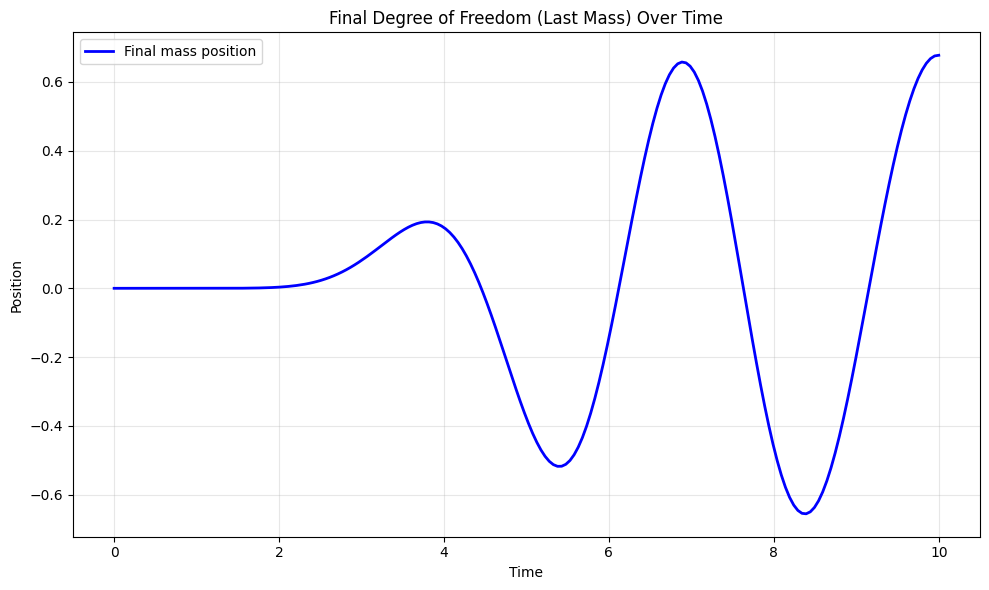

Final mass trajectory range: [-0.6557, 0.6777]


In [5]:
# Cell 5: Plot the final DOF over time
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(ts, target_traj, 'b-', linewidth=2, label='Final mass position')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Final Degree of Freedom (Last Mass) Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final mass trajectory range: [{target_traj.min():.4f}, {target_traj.max():.4f}]")


In [6]:
# Cell 4: Define and evaluate the loss
def loss_fn(p):
    states = odeint(dynamics, init_state, ts, p)
    x_end  = states[:, N-1]
    return 0.5 * jnp.trapezoid((x_end - target_traj)**2, ts)

p_test = p_true * 1.1
print("Loss at p_test:", loss_fn(p_test))


Loss at p_test: 0.08159862


In [7]:
# Cell 7: Compute the adjoint‐based gradient

# (a) replay forward trajectory at p_test
states = odeint(dynamics, init_state, ts, p_test)

# (b) interpolation helper for target_traj
def target_interp(t):
    return jnp.interp(t, ts, target_traj)

# (c) interpolation helper for state trajectory
def state_interp(t, states_traj):
    # Interpolate each component of the state vector
    state_components = []
    for i in range(states_traj.shape[1]):
        component = jnp.interp(t, ts, states_traj[:, i])
        state_components.append(component)
    return jnp.array(state_components)

# (d) running‐cost gradient: ∇_u g = (x_end - target) on DOF N-1
def running_cost_grad(state, t):
    x, v = jnp.split(state, 2)
    gx = jnp.zeros_like(x).at[N-1].set(x[N-1] - target_interp(t))
    gv = jnp.zeros_like(v)
    return jnp.concatenate([gx, gv])  # gradient wrt [x, v] = [∇_x g, 0]

# (e) Jacobian of dynamics wrt state
jac_dyn = jax.jacfwd(dynamics, argnums=0)

# (f) adjoint ODE: da/dt = -J^T a - ∇g
def adjoint_ode(a, t, p, states_traj):
    u = state_interp(t, states_traj)
    J = jac_dyn(u, t, p)
    return (J.T @ a) - running_cost_grad(u, t)

# integrate adjoint backward in time
# For backward integration, we need to reverse time: τ = T - t
T = t_final
def adjoint_ode_reversed(a, tau, p, states_traj):
    t = T - tau  # convert back to forward time
    return adjoint_ode(a, t, p, states_traj)  # negative because we're going backward

tau_span = jnp.linspace(0.0, T, num_steps)  # τ goes from 0 to T
aT = jnp.zeros(2 * N)  # terminal condition a(T) = 0

# Integrate backward
a_rev = odeint(lambda a, tau: adjoint_ode_reversed(a, tau, p_test, states), 
               aT, tau_span, rtol=1e-12, atol=1e-12)

# Convert back to forward time order
a_traj = a_rev[::-1]

print("Adjoint trajectory shape:", a_traj.shape)
print("Forward states shape:", states.shape)

Adjoint trajectory shape: (200, 10)
Forward states shape: (200, 10)


In [8]:
# Cell 8: Form the gradient integral and compare to autodiff

# (f) Jacobian of dynamics wrt parameters
jac_params = jax.jacfwd(dynamics, argnums=2)

# build overlap integrand a^T ∂_p f for the adjoint gradient formula
ints = []
for a, u, t in zip(a_traj, states, ts):
    Jp = jac_params(u, t, p_test)            # shape (2N, num_params)
    ints.append((a[:, None].T @ Jp)[0])      # (1, num_params) -> (num_params,)
ints = jnp.stack(ints)                       # (num_steps, num_params)

# gradient from adjoint formula: ∇_p J = ∫ a^T ∂f/∂p dt
grad_adjoint = -jnp.trapezoid(ints, ts, axis=0)
print("Adjoint gradient:", grad_adjoint)

# autodiff for verification
grad_auto = jax.grad(loss_fn)(p_test)
print("Autodiff gradient:", grad_auto)

print("\nDifference:", grad_adjoint - grad_auto)
print("Relative error:", jnp.abs(grad_adjoint - grad_auto) / (jnp.abs(grad_auto) + 1e-8))

# Normalized gradient comparisons and overlaps
def normalize_gradient(grad):
    norm = jnp.linalg.norm(grad)
    return grad / (norm + 1e-12)  # add small epsilon to avoid division by zero

grad_adjoint_norm = normalize_gradient(grad_adjoint)
grad_auto_norm = normalize_gradient(grad_auto)

print("\n--- Normalized Gradient Analysis ---")
print("Adjoint gradient (normalized):", grad_adjoint_norm)
print("Autodiff gradient (normalized):", grad_auto_norm)
print("Normalized difference:", grad_adjoint_norm - grad_auto_norm)
print("Normalized difference norm:", jnp.linalg.norm(grad_adjoint_norm - grad_auto_norm))

# Compute overlap (dot product) between normalized gradients
overlap = jnp.dot(grad_adjoint_norm, grad_auto_norm)
print(f"\nOverlap (Adjoint · Autodiff): {overlap:.8f}")
print(f"Overlap percentage: {overlap * 100:.6f}%")

# Additional angle information
angle_rad = jnp.arccos(jnp.clip(overlap, -1.0, 1.0))
angle_deg = angle_rad * 180.0 / jnp.pi
print(f"Angle between gradients: {angle_deg:.6f} degrees")

if overlap > 0.999:
    print("✓ Excellent agreement: gradients are nearly identical in direction")
elif overlap > 0.99:
    print("✓ Very good agreement: gradients point in very similar directions")
elif overlap > 0.9:
    print("✓ Good agreement: gradients point in similar directions")
else:
    print("⚠ Poor agreement: gradients have significant directional differences")

Adjoint gradient: [ 0.0997269   0.02988646  0.10327501  0.10327553  0.02988564  0.09972682
 -0.         -0.         -0.         -0.         -0.        ]
Autodiff gradient: [0.09982828 0.02991886 0.10337566 0.10337554 0.02991896 0.09982815
 0.         0.         0.         0.         0.        ]

Difference: [-1.0138005e-04 -3.2393262e-05 -1.0064989e-04 -1.0000914e-04
 -3.3320859e-05 -1.0133535e-04 -0.0000000e+00 -0.0000000e+00
 -0.0000000e+00 -0.0000000e+00 -0.0000000e+00]
Relative error: [0.00101554 0.0010827  0.00097363 0.00096744 0.0011137  0.0010151
 0.         0.         0.         0.         0.        ]

--- Normalized Gradient Analysis ---
Adjoint gradient (normalized): [ 0.4808766   0.14411058  0.49798533  0.49798784  0.1441066   0.48087618
 -0.         -0.         -0.         -0.         -0.        ]
Autodiff gradient (normalized): [0.4808857  0.14412299 0.4979739  0.4979733  0.14412348 0.4808851
 0.         0.         0.         0.         0.        ]
Normalized difference: [

In [9]:
def dynamics_time_mirror_forcing(state, t, p):
    # state = [x_0, ..., x_{N-1}, v_0, ..., v_{N-1}]
    x, v = jnp.split(state, 2)
    k_springs, beta = unpack_params(p)

    # fixed‐end springs → pad x with zeros at both ends
    x_pad = jnp.concatenate([jnp.array([0.0]), x, jnp.array([0.0])])
    
    # linear spring forces with individual spring constants
    # For mass i: force = -k[i]*(x[i] - x[i-1]) - k[i+1]*(x[i] - x[i+1])
    Kx = jnp.zeros_like(x)
    for i in range(N):
        # Left spring force: -k_springs[i] * (x[i] - x_pad[i])
        # Right spring force: -k_springs[i+1] * (x[i] - x_pad[i+2])
        Kx = Kx.at[i].set(k_springs[i] * (x_pad[i] - x[i]) + k_springs[i+1] * (x_pad[i+2] - x[i]))
    
    # local Duffing nonlinearity
    duff = -0*beta * x**3
    # acceleration
    a = ( Kx + duff + forcing(T-t)) / mass

    return jnp.concatenate([v, a])

In [ ]:
# Cell 10: ε-rule as a function with gradient comparisons

def compute_eps_gradient(epsilon):
    """Compute gradient using ε-rule for given epsilon value"""
    # For pure running cost problems (no terminal cost):
    # w(0) = u(0) (same initial condition - no terminal cost perturbation)
    w0 = states[-1]
    w0 = jnp.concatenate([w0[0:N], -w0[N:]])

    # Define modified dynamics: dw/dt = f(w,t,p) + ε·∇g(w,t) 
    def w_dynamics(w, t, p):
        base = dynamics_time_mirror_forcing(w, t, p)
        rung = running_cost_grad(w, T-t)   # ∇g at each time
        return base - epsilon * rung

    # Integrate the perturbed system forward
    w_states = odeint(w_dynamics, w0, ts, p_test, rtol=1e-12, atol=1e-12)

    x_rev = w_states[:, 0:N][::-1]
    v_rev = -w_states[:, N:][::-1]
    u_rev = jnp.concatenate([x_rev, v_rev], axis=1)   # shape (num_steps,2N)
    # Extract the difference v = w - u
    v_states = u_rev - states

    # Gradient via ε-rule: ∇_p J = (1/ε) * ∫ v^T * ∂f/∂p dt
    ints = []
    for v, u, t in zip(v_states, states, ts):
        Jp = jax.jacfwd(dynamics, argnums=2)(u, t, p_test)  # ∂f/∂p
        ints.append((v[:, None].T @ Jp)[0])
    ints = jnp.stack(ints)

    grad_eps =  - (1/epsilon) * jnp.trapezoid(ints, ts, axis=0)
    return grad_eps

# Test the function and compare gradients
ε = 1
grad_eps = compute_eps_gradient(ε)

print("ε-rule gradient:", grad_eps)
print("Adjoint gradient:", grad_adjoint)
print("Autodiff gradient:", grad_auto)

print("\nε-rule vs Adjoint difference:", grad_eps - grad_adjoint)
print("ε-rule vs Autodiff difference:", grad_eps - grad_auto)

# Compute normalized gradients
def normalize_grad(grad):
    norm = jnp.linalg.norm(grad)
    return grad / (norm + 1e-12)  # add small epsilon to avoid division by zero

grad_eps_norm = normalize_grad(grad_eps)
grad_adjoint_norm = normalize_grad(grad_adjoint)
grad_auto_norm = normalize_grad(grad_auto)

print("\n--- Normalized Gradient Comparisons ---")
print("ε-rule normalized:", grad_eps_norm)
print("Adjoint normalized:", grad_adjoint_norm)
print("Autodiff normalized:", grad_auto_norm)

print("\nNormalized ε-rule vs Adjoint difference:", grad_eps_norm - grad_adjoint_norm)
print("Normalized ε-rule vs Autodiff difference:", grad_eps_norm - grad_auto_norm)
print("Normalized Adjoint vs Autodiff difference:", grad_adjoint_norm - grad_auto_norm)

# Dot products to check directional similarity
print("\n--- Directional Similarity (Dot Products) ---")
print("ε-rule · Adjoint:", jnp.dot(grad_eps_norm, grad_adjoint_norm))
print("ε-rule · Autodiff:", jnp.dot(grad_eps_norm, grad_auto_norm))
print("Adjoint · Autodiff:", jnp.dot(grad_adjoint_norm, grad_auto_norm))


ε-rule gradient: [-0.28002408 -0.10477796 -0.2526682  -0.2526313  -0.13020155 -0.29919505
  0.          0.          0.          0.          0.        ]
Adjoint gradient: [ 0.0997269   0.02988646  0.10327501  0.10327553  0.02988564  0.09972682
 -0.         -0.         -0.         -0.         -0.        ]
Autodiff gradient: [0.09982828 0.02991886 0.10337566 0.10337554 0.02991896 0.09982815
 0.         0.         0.         0.         0.        ]

ε-rule vs Adjoint difference: [-0.37975097 -0.13466443 -0.3559432  -0.35590684 -0.16008718 -0.39892188
  0.          0.          0.          0.          0.        ]
ε-rule vs Autodiff difference: [-0.37985235 -0.13469681 -0.35604388 -0.35600686 -0.1601205  -0.3990232
  0.          0.          0.          0.          0.        ]

--- Normalized Gradient Comparisons ---
ε-rule normalized: [-0.49231255 -0.18421097 -0.44421798 -0.4441531  -0.22890837 -0.5260172
  0.          0.          0.          0.          0.        ]
Adjoint normalized: [ 0.480

In [11]:
# Cell 11: Epsilon sweep and log-log plots

# Define range of epsilon values (logarithmically spaced)
epsilons = jnp.linspace(1e-4, 1e0, 10)  # from 1e-6 to 1e-1
print(f"Testing {len(epsilons)} epsilon values from {epsilons[0]:.1e} to {epsilons[-1]:.1e}")

# Compute gradients for each epsilon
eps_gradients = []
for i, eps in enumerate(epsilons):
    print(f"Computing gradient {i+1}/{len(epsilons)} for ε = {eps:.1e}", end='\r')
    grad = compute_eps_gradient(eps)
    eps_gradients.append(grad)

eps_gradients = jnp.array(eps_gradients)
print(f"\nCompleted gradient computations. Shape: {eps_gradients.shape}")

# Compute errors (differences from autodiff)
errors_raw = jnp.linalg.norm(eps_gradients - grad_auto[None, :], axis=1)
errors_normalized = []

for grad_eps in eps_gradients:
    # Normalize both gradients
    grad_eps_norm = grad_eps / (jnp.linalg.norm(grad_eps) + 1e-12)
    grad_auto_norm = grad_auto / (jnp.linalg.norm(grad_auto) + 1e-12)
    # Compute normalized error
    error_norm = jnp.linalg.norm(grad_eps_norm - grad_auto_norm)
    errors_normalized.append(error_norm)

errors_normalized = jnp.array(errors_normalized)

print(f"Raw errors range: {errors_raw.min():.2e} to {errors_raw.max():.2e}")
print(f"Normalized errors range: {errors_normalized.min():.2e} to {errors_normalized.max():.2e}")


Testing 10 epsilon values from 1.0e-04 to 1.0e+00


KeyboardInterrupt: 

In [ ]:
errors_normalized

In [ ]:
# Cell 12: Create log-log plots

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Raw (non-normalized) errors
ax1.loglog(epsilons, errors_raw, 'bo-', linewidth=2, markersize=6, label='ε-rule vs Autodiff')
ax1.loglog(epsilons, epsilons, 'k--', alpha=0.7, label='ε (linear reference)')
ax1.loglog(epsilons, epsilons**2, 'r--', alpha=0.7, label='ε² (quadratic reference)')
ax1.set_xlabel('ε (epsilon)', fontsize=12)
ax1.set_ylabel('||∇ε - ∇autodiff||', fontsize=12)
ax1.set_title('Raw Gradient Error vs ε', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Normalized errors
ax2.loglog(epsilons, errors_normalized, 'ro-', linewidth=2, markersize=6, label='Normalized ε-rule vs Autodiff')
ax2.loglog(epsilons, epsilons, 'k--', alpha=0.7, label='ε (linear reference)')
ax2.loglog(epsilons, epsilons**2, 'g--', alpha=0.7, label='ε² (quadratic reference)')
ax2.set_xlabel('ε (epsilon)', fontsize=12)
ax2.set_ylabel('||∇ε/||∇ε|| - ∇auto/||∇auto|| ||', fontsize=12)
ax2.set_title('Normalized Gradient Error vs ε', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Find optimal epsilon values
min_raw_idx = jnp.argmin(errors_raw)
min_norm_idx = jnp.argmin(errors_normalized)

print(f"\nOptimal ε for raw error: {epsilons[min_raw_idx]:.2e} (error: {errors_raw[min_raw_idx]:.2e})")
print(f"Optimal ε for normalized error: {epsilons[min_norm_idx]:.2e} (error: {errors_normalized[min_norm_idx]:.2e})")

# Check convergence rate for small epsilon
small_eps_mask = epsilons < 1e-3
if jnp.sum(small_eps_mask) > 3:
    small_epsilons = epsilons[small_eps_mask]
    small_errors = errors_raw[small_eps_mask]
    
    # Fit log(error) = a + b*log(epsilon) to find convergence rate
    log_eps = jnp.log(small_epsilons)
    log_err = jnp.log(small_errors)
    
    # Simple linear regression
    A = jnp.vstack([log_eps, jnp.ones(len(log_eps))]).T
    slope, intercept = jnp.linalg.lstsq(A, log_err, rcond=None)[0]
    
    print(f"\nFor small ε, error ∝ ε^{slope:.2f} (slope = {slope:.2f})")
    if jnp.abs(slope - 1) < 0.1:
        print("→ Linear convergence confirmed!")
    elif jnp.abs(slope - 2) < 0.1:
        print("→ Quadratic convergence confirmed!")
